# 🔍 Model Interpretation and Analysis
This notebook focuses on interpreting the trained XGBoost model by analyzing feature importance, comparing actual and predicted trip durations, evaluating residual errors, and identifying the strengths and limitations of the final model before deployment.

In [4]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TRAIN_PROCESSED_PATH
from src.config import MODEL_PATH
from src.config import FEATURE_PATH

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
model = joblib.load(MODEL_PATH)

feature_columns = joblib.load(FEATURE_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
df = pd.read_csv(TRAIN_PROCESSED_PATH)
df.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day,...,is_weekend,dropoff_year,dropoff_month,dropoff_day,dropoff_weekday,dropoff_hour,dropoff_minute,haversine_distance,manhattan_distance,bearing
0,1,-73.982155,40.767937,-73.964630,40.765602,0,455,2016,3,14,...,0,2016,3,14,0,17,32,1.498521,0.019859,99.970196
1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,2016,6,12,...,1,2016,6,12,6,0,54,1.805507,0.026478,242.846232
2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,2016,1,19,...,0,2016,1,19,1,12,10,6.385098,0.080158,200.319835
3,1,-74.010040,40.719971,-74.012268,40.706718,0,429,2016,4,6,...,0,2016,4,6,2,19,39,1.485498,0.015480,187.262300
4,1,-73.973053,40.793209,-73.972923,40.782520,0,435,2016,3,26,...,1,2016,3,26,5,13,38,1.188588,0.010818,179.473585


In [15]:
X = df.drop('trip_duration', axis=1)
y = np.log1p(df['trip_duration'])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
y_pred = model.predict(X_test)

In [18]:
y_test_original = np.expm1(y_test)

y_pred_original = np.expm1(y_pred)

In [19]:
mae = mean_absolute_error(y_test_original, y_pred_original)

mse = mean_squared_error(y_test_original, y_pred_original)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_original, y_pred_original)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 62.14
MSE : 23111.34
RMSE: 152.02
R²  : 0.9452


## Actual vs Predicted Values

Visualize how closely the predicted trip durations match the actual trip durations.

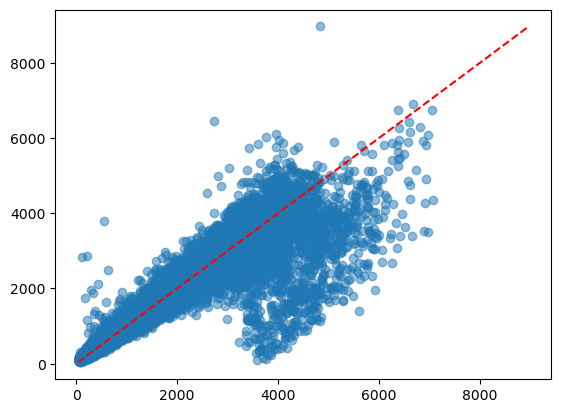

In [28]:
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--"
)

## Residual Analysis

Analyze the residual errors to determine whether prediction errors are randomly distributed.

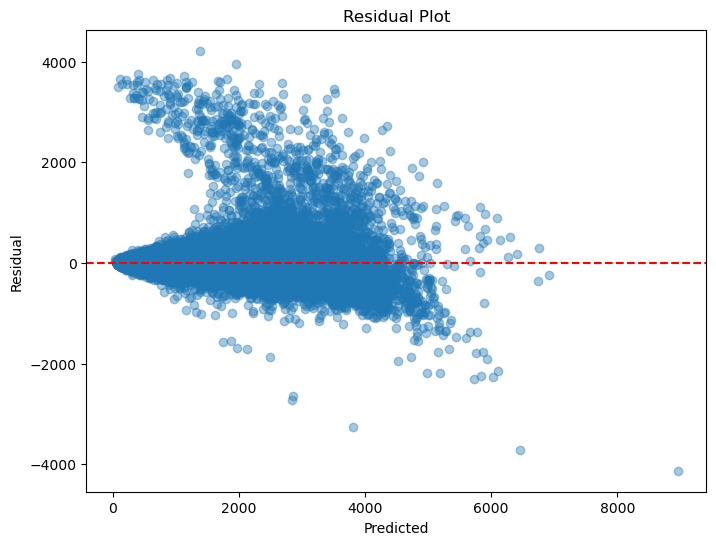

In [21]:
residuals = y_test_original - y_pred_original

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_original,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

## Feature Importance

Identify the features that contribute the most to the XGBoost model's predictions.

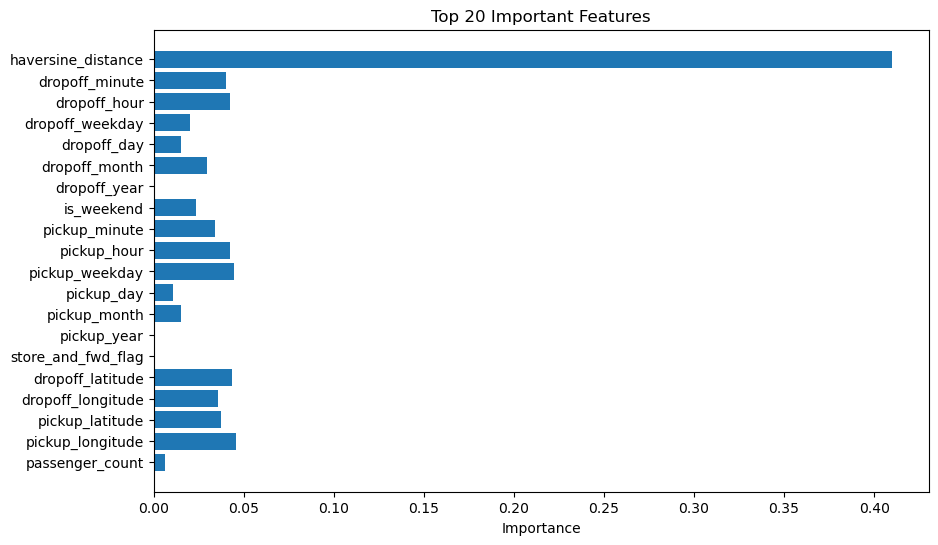

In [30]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.xlabel("Importance")

plt.title("Top 20 Important Features")

plt.show()

## Key Findings

- The optimized XGBoost model achieved strong predictive performance on unseen data.
- Distance-related features contributed the most to predicting trip duration.
- Residual analysis indicated that prediction errors were reasonably distributed.
- The model generalizes well and is suitable for deployment.